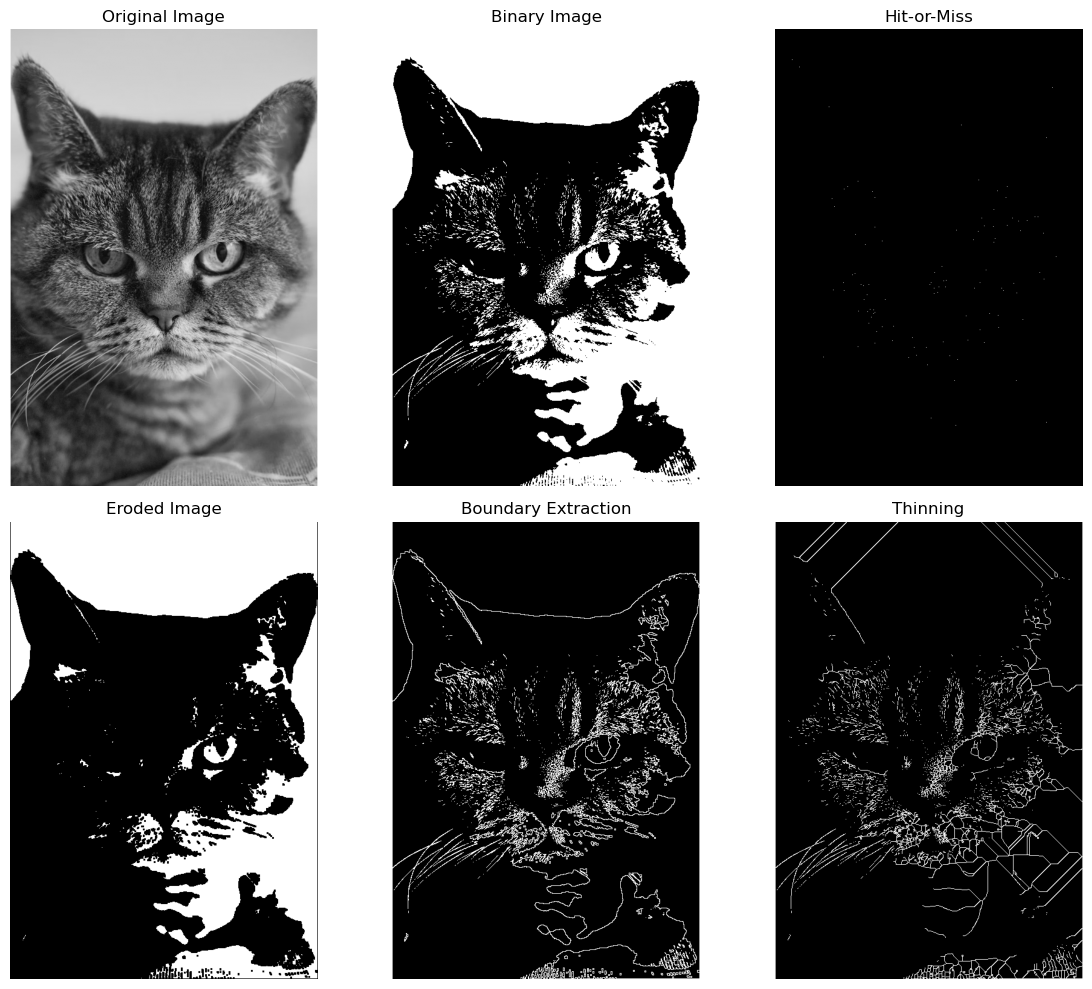

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Change this to your image location on your PC

# Read image from PC
image = cv2.imread("cat.png", cv2.IMREAD_GRAYSCALE)

# Convert to binary image
_, binary = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)
binary = (binary > 0).astype(np.uint8)

# ---------------------------------------------------
# 1. Hit-or-Miss Transform
#    1 = foreground
#    0 = background
#   -1 = don't care
# ---------------------------------------------------
def hit_or_miss(img, kernel):
    img = (img > 0).astype(np.uint8)
    kernel = np.asarray(kernel, dtype=np.int8)

    h, w = img.shape
    kh, kw = kernel.shape
    pad_h = kh // 2
    pad_w = kw // 2

    result = np.zeros_like(img, dtype=np.uint8)

    for y in range(h):
        for x in range(w):
            ok = True
            for ky in range(kh):
                for kx in range(kw):
                    val = kernel[ky, kx]
                    yy = y + ky - pad_h
                    xx = x + kx - pad_w

                    if val == -1:
                        continue

                    if yy < 0 or yy >= h or xx < 0 or xx >= w:
                        pixel = 0
                    else:
                        pixel = img[yy, xx]

                    if val == 1 and pixel != 1:
                        ok = False
                        break
                    if val == 0 and pixel != 0:
                        ok = False
                        break

                if not ok:
                    break

            if ok:
                result[y, x] = 1

    return result

# ---------------------------------------------------
# 2. Erosion
# ---------------------------------------------------
def erosion(img, kernel):
    img = (img > 0).astype(np.uint8)
    kernel = np.asarray(kernel, dtype=np.uint8)

    h, w = img.shape
    kh, kw = kernel.shape
    pad_h = kh // 2
    pad_w = kw // 2
    result = np.zeros_like(img, dtype=np.uint8)

    for y in range(h):
        for x in range(w):
            valid = True
            for ky in range(kh):
                for kx in range(kw):
                    if kernel[ky, kx] == 0:
                        continue

                    yy = y + ky - pad_h
                    xx = x + kx - pad_w

                    if yy < 0 or yy >= h or xx < 0 or xx >= w:
                        valid = False
                        break

                    if img[yy, xx] == 0:
                        valid = False
                        break

                if not valid:
                    break

            if valid:
                result[y, x] = 1

    return result

# ---------------------------------------------------
# 3. Boundary Extraction
#    Boundary = Original - Eroded
# ---------------------------------------------------
def boundary_extraction(img, kernel):
    eroded = erosion(img, kernel)
    boundary = (img > 0).astype(np.uint8) - eroded
    return np.clip(boundary, 0, 1).astype(np.uint8)

# ---------------------------------------------------
# 4. Thinning using Zhang-Suen algorithm
# ---------------------------------------------------
def thinning_zhang_suen(img):
    img = (img > 0).astype(np.uint8)
    changed = True

    while changed:
        changed = False
        to_delete = []

        # First sub-iteration
        for y in range(1, img.shape[0] - 1):
            for x in range(1, img.shape[1] - 1):
                if img[y, x] == 0:
                    continue

                p2 = img[y - 1, x]
                p3 = img[y - 1, x + 1]
                p4 = img[y, x + 1]
                p5 = img[y + 1, x + 1]
                p6 = img[y + 1, x]
                p7 = img[y + 1, x - 1]
                p8 = img[y, x - 1]
                p9 = img[y - 1, x - 1]

                neighbors = [p2, p3, p4, p5, p6, p7, p8, p9]
                n = sum(neighbors)
                transitions = 0

                for a, b in zip(neighbors, neighbors[1:] + neighbors[:1]):
                    if a == 0 and b == 1:
                        transitions += 1

                if 2 <= n <= 6 and transitions == 1 and p2 * p4 * p6 == 0 and p4 * p6 * p8 == 0:
                    to_delete.append((y, x))

        for y, x in to_delete:
            img[y, x] = 0
            changed = True

        # Second sub-iteration
        to_delete = []

        for y in range(1, img.shape[0] - 1):
            for x in range(1, img.shape[1] - 1):
                if img[y, x] == 0:
                    continue

                p2 = img[y - 1, x]
                p3 = img[y - 1, x + 1]
                p4 = img[y, x + 1]
                p5 = img[y + 1, x + 1]
                p6 = img[y + 1, x]
                p7 = img[y + 1, x - 1]
                p8 = img[y, x - 1]
                p9 = img[y - 1, x - 1]

                neighbors = [p2, p3, p4, p5, p6, p7, p8, p9]
                n = sum(neighbors)
                transitions = 0

                for a, b in zip(neighbors, neighbors[1:] + neighbors[:1]):
                    if a == 0 and b == 1:
                        transitions += 1

                if 2 <= n <= 6 and transitions == 1 and p2 * p4 * p8 == 0 and p2 * p6 * p8 == 0:
                    to_delete.append((y, x))

        for y, x in to_delete:
            img[y, x] = 0
            changed = True

    return img.astype(np.uint8)

# ---------------------------------------------------
# Example kernel for Hit-or-Miss
# ---------------------------------------------------
kernel_hitmiss = np.array([
    [1,  1,  1],
    [0,  1,  0],
    [-1, 0, -1]
], dtype=np.int8)

kernel3 = np.ones((3, 3), dtype=np.uint8)

# Apply operations to the image from your PC
hit_miss = hit_or_miss(binary, kernel_hitmiss)
eroded = erosion(binary, kernel3)
boundary = boundary_extraction(binary, kernel3)
thinned = thinning_zhang_suen(binary)

# Display results
plt.figure(figsize=(12, 10))

plt.subplot(2, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(binary, cmap="gray")
plt.title("Binary Image")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(hit_miss, cmap="gray")
plt.title("Hit-or-Miss")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(eroded, cmap="gray")
plt.title("Eroded Image")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(boundary, cmap="gray")
plt.title("Boundary Extraction")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(thinned, cmap="gray")
plt.title("Thinning")
plt.axis("off")

plt.tight_layout()
plt.show()